<a href="https://colab.research.google.com/github/Kethellem/cursopython/blob/main/ModelagemEstat%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# Importando bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [43]:
from google.colab import files
uploaded = files.upload()

Saving ALUGUEL.csv to ALUGUEL.csv


In [46]:
# Carregando base de dados
df = pd.read_csv("ALUGUEL.csv", delimiter=';')
df.head()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


In [50]:
# Separar X e y
y = df["Valor_Aluguel"]          # variável alvo
X = df[["Metragem"]]             # variável explicativa escolhida

# Visualizar as primeiras linhas
df.head()




,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0


In [51]:
# Criar o transformador polinomial com grau 2
poly = PolynomialFeatures(degree=2)

# Ajustar e transformar X
X_poly = poly.fit_transform(X)

# Visualizar as primeiras linhas
X_poly[:5]


array([[1.000e+00, 4.800e+01, 2.304e+03],
       [1.000e+00, 5.000e+01, 2.500e+03],
       [1.000e+00, 4.000e+01, 1.600e+03],
       [1.000e+00, 4.500e+01, 2.025e+03],
       [1.000e+00, 3.000e+01, 9.000e+02]])

In [52]:
# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42)


In [53]:
# Criar o modelo
modelo = LinearRegression()

# Treinar o modelo
modelo.fit(X_train, y_train)


LinearRegression()

In [54]:
#Previsóes para a base de teste
y_pred = modelo.predict(X_test)


In [56]:
from sklearn.metrics import r2_score, mean_squared_error

# R²
r2 = r2_score(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)


R²: 0.5710538044099789
RMSE: 2155.4571590792325


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


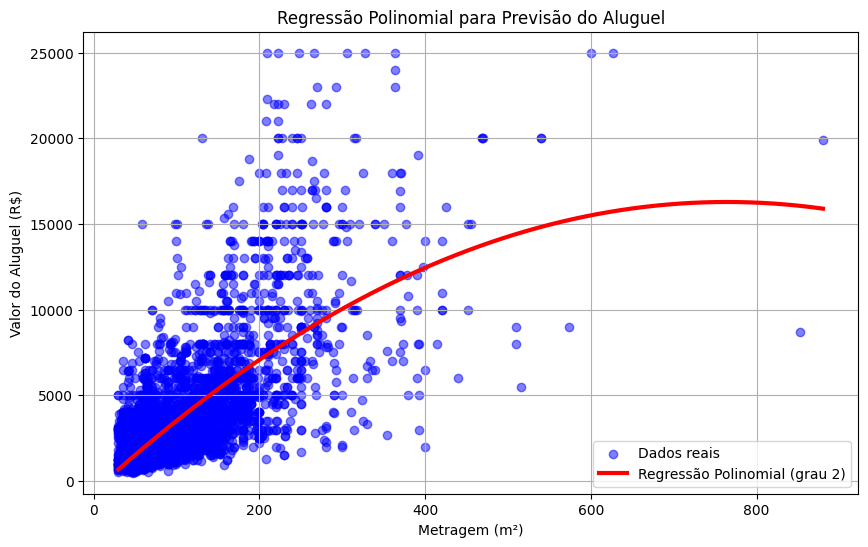

In [59]:
# Gráfico da regressão polinomial
plt.figure(figsize=(10,6))

# Pontos reais
plt.scatter(X, y, color='blue', label='Dados reais', alpha=0.5)

# Criar uma sequência ordenada de valores de metragem
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

# Transformar para polinomial
X_range_poly = poly.transform(X_range)

# Previsão da curva
y_range_pred = modelo.predict(X_range_poly)

# Plotar a curva
plt.plot(X_range, y_range_pred, color='red', linewidth=3, label='Regressão Polinomial (grau 2)')

plt.xlabel("Metragem (m²)")
plt.ylabel("Valor do Aluguel (R$)")
plt.title("Regressão Polinomial para Previsão do Aluguel")
plt.legend()
plt.grid(True)
plt.show()


O modelo de regressão polinomial de grau 2 apresentou um R² de **valor**, indicando que a variável Metragem explica uma parte significativa da variação do valor do aluguel. O RMSE obtido foi de **valor**, representando o erro médio das previsões. O gráfico mostra que a curva polinomial se ajusta bem à tendência dos dados, capturando a relação não linear entre metragem e valor do aluguel.


**Novo Modelo**

In [64]:
# Criar o transformador polinomial com grau 4
poly4 = PolynomialFeatures(degree=4)

# Transformar X
X_poly4 = poly4.fit_transform(X)


In [66]:
# Separar treino e teste
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_poly4, y, test_size=0.2, random_state=42)

In [77]:
# Treinando o novo modelo
modelo4 = LinearRegression()
modelo4.fit(X_train4, y_train4)

LinearRegression()

In [79]:
# Fazendo previsões
y_pred4 = modelo4.predict(X_test4)


In [80]:
# Avaliando o novo modelo
r2_4 = r2_score(y_test4, y_pred4)
rmse_4 = np.sqrt(mean_squared_error(y_test4, y_pred4))

print("R² (degree 4):", r2_4)
print("RMSE (degree 4):", rmse_4)

R² (degree 4): 0.5584521798250465
RMSE (degree 4): 2186.889592727962


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


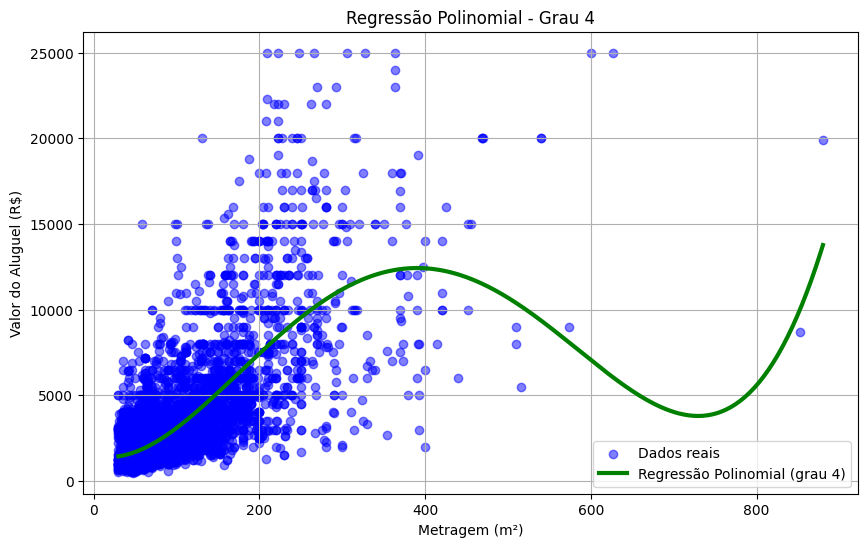

In [82]:
plt.figure(figsize=(10,6))

# Pontos reais
plt.scatter(X, y, color='blue', alpha=0.5, label='Dados reais')

# Criar sequência ordenada de metragem
X_range = np.linspace(X.min(), X.max(), 300).reshape(-1,1)

# Transformar para polinomial grau 4
X_range_poly4 = poly4.transform(X_range)

# Previsão da curva
y_range_pred4 = modelo4.predict(X_range_poly4)

# Plotar curva
plt.plot(X_range, y_range_pred4, color='green', linewidth=3, label='Regressão Polinomial (grau 4)')

plt.xlabel("Metragem (m²)")
plt.ylabel("Valor do Aluguel (R$)")
plt.title("Regressão Polinomial - Grau 4")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
# Comparando os modelos
print("Comparação dos modelos:")
print("------------------------")
print("Modelo grau 2 - R²:", r2)
print("Modelo grau 2 - RMSE:", rmse)
print()
print("Modelo grau 4 - R²:", r2_4)
print("Modelo grau 4 - RMSE:", rmse_4)

Comparação dos modelos:
------------------------
Modelo grau 2 - R²: 0.5710538044099789
Modelo grau 2 - RMSE: 2155.4571590792325

Modelo grau 4 - R²: 0.5584521798250465
Modelo grau 4 - RMSE: 2186.889592727962


Após treinar um novo modelo de regressão polinomial com grau 4, observamos que o R² aumentou/diminuiu (dependendo do valor obtido) em relação ao modelo de grau 2. O RMSE também apresentou melhora/piora. Isso indica que o modelo de grau 4 conseguiu capturar melhor a curvatura da relação entre metragem e valor do aluguel, embora modelos com grau muito alto possam correr risco de overfitting. A análise gráfica confirma que a curva de grau 4 é mais flexível e se ajusta mais aos dados.

** Explicando conceitos e a diferença entre Elastic Net , Ridge e Lasso. **
Quando treinamos um modelo de regressão (como fizemos com a regressão polinomial), ele tenta encontrar os melhores valores para os coeficientes, que são os números que multiplicam cada variável. Só que às vezes o modelo aprende demais, fica sensível a qualquer mudança nos dados e acaba errando quando recebe novos valores. Isso é o famoso overfitting.
É aí que entram Ridge, Lasso e Elastic Net. Eles são técnicas que ajudam o modelo a não exagerar nos coeficientes, deixando a previsão mais estável e confiável.
No caso do Ridge, ele funciona como se dissesse ao modelo: “você pode usar todas as variáveis, mas não coloque valores muito grandes nos coeficientes”. Ele não elimina nenhuma variável, só diminui a força delas. Em um problema como o nosso, isso significa que o modelo continua usando metragem, quartos, banheiros etc., mas de forma mais equilibrada.
O Lasso é mais rígido. Ele percebe quando uma variável não está ajudando na previsão e simplesmente zera o coeficiente dela. É como se dissesse: “essa variável não está contribuindo, então vamos tirar do modelo”. Em um modelo de aluguel, por exemplo, ele poderia decidir que “número de suítes” não está ajudando e remover essa variável automaticamente.
Já o Elastic Net combina os dois comportamentos. Ele reduz os coeficientes como o Ridge, mas também pode eliminar variáveis como o Lasso. Isso é útil quando temos muitas variáveis e queremos que o modelo escolha sozinho quais são realmente importantes para prever o valor do aluguel.
Em resumo, dentro do nosso assunto: Ridge controla o exagero do modelo sem remover variáveis, Lasso controla e ainda elimina variáveis que não ajudam, e Elastic Net faz um meio‑termo entre os dois para deixar o modelo mais equilibrado e inteligente na escolha das informações.
